In [3]:
# Install (run only once if not installed)
!pip install datasets transformers

In [4]:
from datasets import load_dataset

# Load AG News dataset
dataset = load_dataset("ag_news")

print(dataset)

/Users/shivrajsinghbhati/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [5]:
# Check one sample
print(dataset['train'][0])

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [6]:
label_names = dataset['train'].features['label'].names
print(label_names)

['World', 'Sports', 'Business', 'Sci/Tech']


In [7]:
#Check Distribution (interview gold)
from collections import Counter

labels = dataset['train']['label']
print(Counter(labels))

Counter({2: 30000, 3: 30000, 1: 30000, 0: 30000})


In [8]:
#Train/Test Split Access
train_data = dataset['train']
test_data = dataset['test']

print(len(train_data), len(test_data))

120000 7600


In [9]:
#Load BERT Tokenizer
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/Users/shivrajsinghbhati/anaconda3/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.9) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/shivrajsinghbhati/anaconda3/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [10]:
#Try Tokenization
sample_text = train_data[0]['text']

encoded = tokenizer(
    sample_text,
    padding='max_length',
    truncation=True,
    max_length=128
)

print(encoded)

{'input_ids': [101, 2813, 2358, 1012, 6468, 15020, 2067, 2046, 1996, 2304, 1006, 26665, 1007, 26665, 1011, 2460, 1011, 19041, 1010, 2813, 2395, 1005, 1055, 1040, 11101, 2989, 1032, 2316, 1997, 11087, 1011, 22330, 8713, 2015, 1010, 2024, 3773, 2665, 2153, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [11]:
#Convert FULL Dataset
def tokenize_function(example):
    return tokenizer(
        example['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)

In [12]:
#Remove Useless Columns
tokenized_dataset = tokenized_dataset.remove_columns(['text'])
tokenized_dataset.set_format('torch')

In [13]:
#Final Check
print(tokenized_dataset['train'][0])

{'label': tensor(2), 'input_ids': tensor([  101,  2813,  2358,  1012,  6468, 15020,  2067,  2046,  1996,  2304,
         1006, 26665,  1007, 26665,  1011,  2460,  1011, 19041,  1010,  2813,
         2395,  1005,  1055,  1040, 11101,  2989,  1032,  2316,  1997, 11087,
         1011, 22330,  8713,  2015,  1010,  2024,  3773,  2665,  2153,  1012,
          102,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,  

In [14]:
#Split Dataset
train_dataset = tokenized_dataset['train']
test_dataset = tokenized_dataset['test']

In [15]:
train_dataset = train_dataset.select(range(10000))
test_dataset = test_dataset.select(range(2000))

In [16]:
#Data Loader
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [17]:
#Load Modal
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4
)

/Users/shivrajsinghbhati/anaconda3/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.decoder.weight', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are

In [18]:
#Device
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(device)

cpu


# training Setup

In [19]:
#Optimizer
from transformers import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

/Users/shivrajsinghbhati/anaconda3/lib/python3.10/site-packages/transformers/optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [24]:
#Training loop
from tqdm import tqdm

model.train()

for epoch in range(3):
    total_loss = 0
    
    loop = tqdm(train_loader, leave=True)
    
    for batch in loop:
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        total_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
        loop.set_description(f"Epoch {epoch}")
        loop.set_postfix(loss=loss.item())
    
    print(f"Epoch {epoch} Loss: {total_loss}")

Epoch 0: 100%|███████████████████| 625/625 [4:04:55<00:00, 23.51s/it, loss=0.19]


Epoch 0 Loss: 234.88229694589972


Epoch 1:   6%|█▏                | 40/625 [07:15<1:46:07, 10.88s/it, loss=0.0461]


KeyboardInterrupt: 

In [20]:
#Evaluation
from sklearn.metrics import accuracy_score, classification_report
import torch

model.eval()

predictions = []
true_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)
        
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

KeyboardInterrupt: 

In [ ]:
#Metrices
print("Accuracy:", accuracy_score(true_labels, predictions))
print("\nClassification Report:\n")
print(classification_report(true_labels, predictions))

In [2]:
#Adding Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

NameError: name 'true_labels' is not defined

In [41]:
#Save model + tokenizer
save_path = "saved_model/bert_ag_news"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("Model and tokenizer saved successfully.")

Model and tokenizer saved successfully.


In [29]:
#Testing single Prediction
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

label_names = ['World', 'Sports', 'Business', 'Sci/Tech']

model_path = "saved_model/bert_ag_news"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

model.to(device)
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [30]:
#now prediction function
def predict_news_category(text):
    inputs = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predicted_class = torch.argmax(logits, dim=1).item()

    return label_names[predicted_class]

In [31]:
sample_news = "Apple announces new AI features for its upcoming iPhone models."
print(predict_news_category(sample_news))

Sci/Tech


In [32]:
#Testing more examples
examples = [
    "The prime minister met foreign leaders to discuss climate policy.",
    "India defeated Australia in the final cricket match.",
    "Stock markets rose after strong quarterly earnings reports.",
    "NASA announced a new mission to study Mars."
]

for text in examples:
    print(text)
    print("Prediction:", predict_news_category(text))
    print("-" * 50)

The prime minister met foreign leaders to discuss climate policy.
Prediction: World
--------------------------------------------------
India defeated Australia in the final cricket match.
Prediction: World
--------------------------------------------------
Stock markets rose after strong quarterly earnings reports.
Prediction: Business
--------------------------------------------------
NASA announced a new mission to study Mars.
Prediction: Sci/Tech
--------------------------------------------------


India defeated Australia in the final cricket match.<br>
Prediction: World<br>
Expected: Sports 

In [40]:
#now giving description
sample = "India defeated Australia in the football World War."
print(predict_news_category(sample))

World


In [42]:
import os

print(os.getcwd())

/Users/shivrajsinghbhati/Desktop/bert-multiclass-news-classification/notebooks


In [43]:
plt.savefig("outputs/plots/confusion_matrix.png")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/shivrajsinghbhati/Desktop/bert-multiclass-news-classification/notebooks/outputs/plots/confusion_matrix.png'

<Figure size 640x480 with 0 Axes>

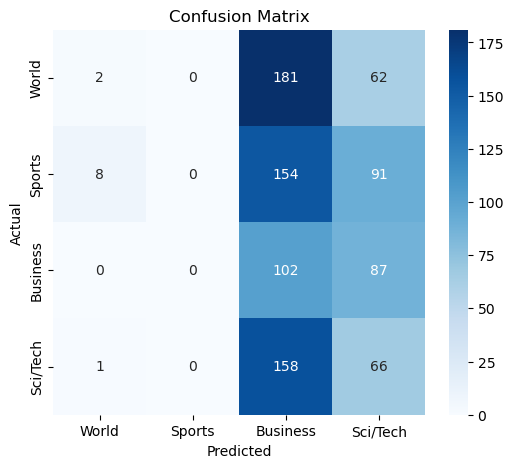

Saved at: /Users/shivrajsinghbhati/Desktop/bert-multiclass-news-classification/outputs/plots/confusion_matrix.png


In [31]:
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = "/Users/shivrajsinghbhati/Desktop/bert-multiclass-news-classification"
save_dir = os.path.join(PROJECT_ROOT, "outputs", "plots")
os.makedirs(save_dir, exist_ok=True)

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

save_path = os.path.join(save_dir, "confusion_matrix.png")

plt.savefig(save_path, bbox_inches="tight", dpi=300)
plt.show()

print("Saved at:", save_path)

In [32]:
ls outputs/plots

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
confusion_matrix.png
